In [2]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.aggregation import group_samples, add_total_cn
from cns.display.plot import plot_lines, fig_lines, fig_dots,  fig_dots, plot_dots
from cns.data_utils import  main_load_data, get_cns_for_type, load_samples_out, load_merged_samples, load_all_samples, load_COSMIC, save_cns_fig
from cns.utils.conversions import segs_to_df, calc_mid

plt.rcParams.update({'font.size': 12})

In [4]:
tcga_samples = load_samples_out("TCGA_hg19_samples.tsv")
len(tcga_samples[tcga_samples["type"] == 'LUAD']) 

472

In [5]:
samples_df, cns_df = main_load_data("1MB")
datasets = samples_df["source"].unique()

In [6]:
luad_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
means_single = [add_total_cn(group_samples(dataset)) for dataset in [v for k, v in luad_dict.items()] + [v for k, v in lusc_dict.items()]]
luad_all = pd.concat([v for k, v in luad_dict.items()])
lusc_all = pd.concat([v for k, v in lusc_dict.items()])
means_all = [add_total_cn(group_samples(dataset)) for dataset in [luad_all, lusc_all]]

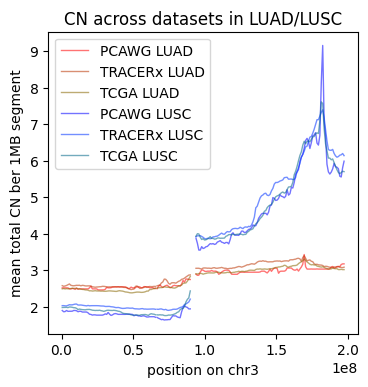

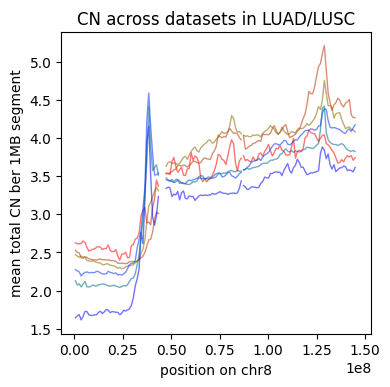

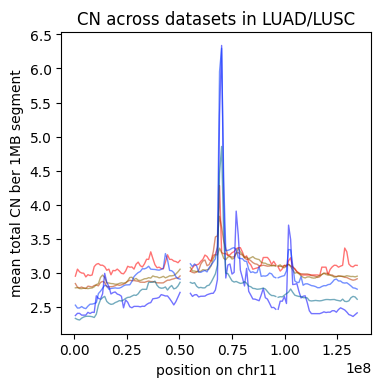

In [7]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
colors = ["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"]
chroms = ["chr3", "chr8", "chr11"]
for chrom in chroms:
	fig, ax = fig_lines(means_single, labels, column="total_cn", color=colors, chrom=chrom)
	ax.set_ylabel("mean total CN ber 1MB segment")
	ax.set_title("CN across datasets in LUAD/LUSC")
	if chrom == "chr3":
		ax.legend(loc='upper left')
	else:
		# disable legend
		ax.legend().set_visible(False)
	save_cns_fig(f"fig_LUAD_LUSC_single_{chrom}")

In [8]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
print("Correlations on 1 Mb segments between datasets")
corr = means_single[3]["total_cn"].corr(means_single[4]["total_cn"], method='pearson')
print("PCAWG-TRACERx", corr)
corr = means_single[3]["total_cn"].corr(means_single[5]["total_cn"], method='pearson')
print("PCAWG-TCGA",corr)
corr = means_single[4]["total_cn"].corr(means_single[5]["total_cn"], method='pearson')
print("TRACERx-TCGA", corr)

Correlations on 1 Mb segments between datasets
PCAWG-TRACERx 0.8851163951724351
PCAWG-TCGA 0.9656743086519441
TRACERx-TCGA 0.8926420527143545


In [9]:
_, cosmic_df = main_load_data("COSMIC")
cosmic_group = group_samples(cosmic_df)
cosmic_group

,chrom,start,end,name,major_cn,minor_cn
0,chr1,2160133,2241558,SKI,1.604735,0.918364
1,chr1,2487077,2496821,TNFRSF14,1.595280,0.914521
2,chr1,2985731,3355185,PRDM16,1.576293,0.906142
3,chr1,6241328,6269449,RPL22,1.570374,0.895380
4,chr1,6845383,7829766,CAMTA1,1.563379,0.891152
...,...,...,...,...,...,...
717,chrX,133507282,133562820,PHF6,1.398109,0.423860
718,chrX,152783133,152848397,ATP2B3,1.420786,0.424245
719,chrX,153576891,153603006,FLNA,1.425628,0.421170
720,chrX,153618314,153637504,RPL10,1.425705,0.421016


In [10]:
cosmic_lusc_df = add_total_cn(get_cns_for_type(cosmic_df, samples_df, "LUSC"))
cosmic_lusc_group = add_total_cn(group_samples(cosmic_lusc_df))
cosmic_luad_df = add_total_cn(get_cns_for_type(cosmic_df, samples_df, "LUAD"))
cosmic_luad_group = add_total_cn(group_samples(cosmic_luad_df))

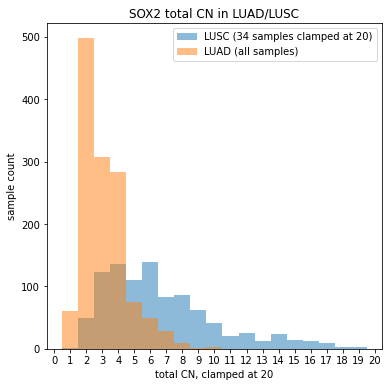

In [11]:
import numpy as np

lusc_SOX2_df = cosmic_lusc_df.query("name == 'SOX2'")
lusc_clamp = sum(lusc_SOX2_df["total_cn"] > 20)
luad_SOX2_df = cosmic_luad_df.query("name == 'SOX2'")
luad_clamp = sum(luad_SOX2_df["total_cn"] > 20)
# plot histogram of SOX2 CN in LUAD and LUSC
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.hist(lusc_SOX2_df["total_cn"], bins=np.arange(0.5, 20.5), alpha=0.5, label=f"LUSC ({lusc_clamp} samples clamped at 20)")
ax.hist(luad_SOX2_df["total_cn"], bins=np.arange(0.5, 20.5), alpha=0.5, label="LUAD (all samples)")
# set xticks to 0-20
ax.set_xticks(np.arange(0, 21))

ax.set_xlabel("total CN, clamped at 20")
ax.set_ylabel("sample count")
ax.set_title("SOX2 total CN in LUAD/LUSC")
ax.legend()

save_cns_fig("fig_SOX2_LUAD_LUSC_hist")

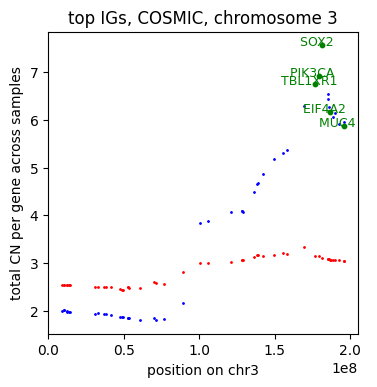

In [12]:
fig, ax = fig_dots(cosmic_lusc_group, chrom="chr3", column="total_cn")
plot_dots(ax, cosmic_luad_group, chrom="chr3", column="total_cn", color="red")
genes = ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]

positions = {
    'EIF4A2': (0, 0),
    'SOX2': (0, 0),
    'TBL1XR1': (0, 0),
    'PIK3CA': (0, 0),
    "MUC4": (0, 0)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in genes:
        mid = calc_mid(row)
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        text = f"{row['name']}"
        x, y = positions[row['name']]
        plt.text(mid + x * 10**8, row['total_cn'] + y, text + "   ", color="green", size=9, ha='center')


ax.set_ylabel("total CN per gene across samples")
plt.title("top IGs, COSMIC, chromosome 3")
save_cns_fig(f"fig_COSMIC_dots_IG_att_chr3")

In [13]:
cosmic_lusc_group

,chrom,start,end,name,major_cn,minor_cn,total_cn
0,chr1,2160133,2241558,SKI,1.848546,0.742227,2.590772
1,chr1,2487077,2496821,TNFRSF14,1.844534,0.739218,2.583751
2,chr1,2985731,3355185,PRDM16,1.831494,0.727182,2.558676
3,chr1,6241328,6269449,RPL22,1.811434,0.728185,2.539619
4,chr1,6845383,7829766,CAMTA1,1.799398,0.717151,2.516550
...,...,...,...,...,...,...,...
717,chrX,133507282,133562820,PHF6,0.841525,0.099298,0.940822
718,chrX,152783133,152848397,ATP2B3,0.868606,0.101304,0.969910
719,chrX,153576891,153603006,FLNA,0.872618,0.099298,0.971916
720,chrX,153618314,153637504,RPL10,0.872618,0.099298,0.971916


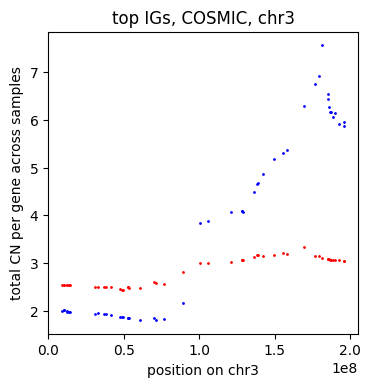

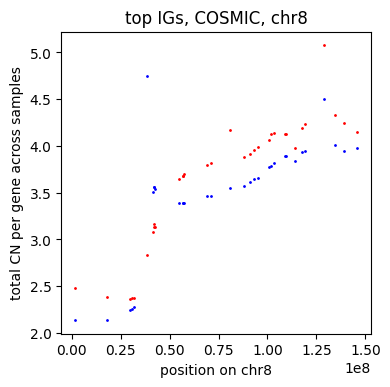

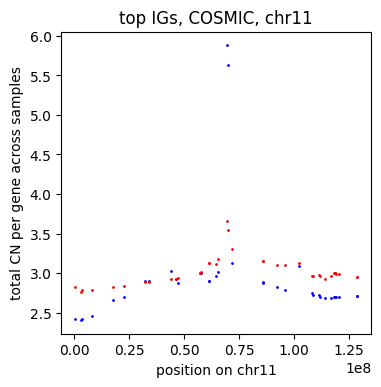

In [14]:
for chrom in chroms:
    fig, ax = fig_dots(cosmic_lusc_group, chrom=chrom, column="total_cn")
    plot_dots(ax, cosmic_luad_group, chrom=chrom, column="total_cn", color="red")

    ax.set_ylabel("total CN per gene across samples")
    plt.title(f"top IGs, COSMIC, {chrom}")
    save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")

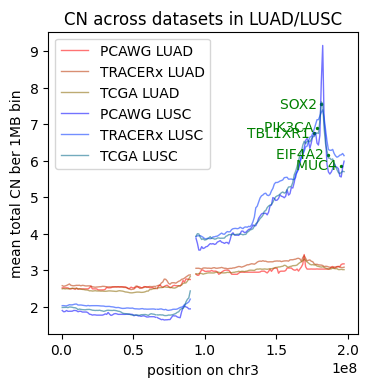

In [15]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"],  chrom="chr3")
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]:
        mid = calc_mid(row)
        plt.scatter(mid, row['total_cn'], color='green', s=2)
        offset = 0
        text = f"{row['name']} "
        plt.text(mid, row['total_cn'] + offset, text, color="green", size=10, ha='right', va='center')

save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")
save_cns_fig(f"fig_COSMIC_lines_IG_att_chr3")